In [1]:

import os
import scipy.io
import h5py
import numpy as np
import sys
from scipy import signal as sig
from scipy import stats as stats
import math
import pandas as pd
import csv
import matplotlib.pyplot as plt
from scipy import signal
import seaborn as sns
import logging

%matplotlib widget


scripts_path = '/home/apolo/Documents/github_projects/ripple_sync/scripts/hc_18_scripts/'
os.chdir(scripts_path)

import hc18_BaseFunctions as hc18_bf

sessions = ['Train-242-20140124','Train-314-20160118','Train-272-20141215','Train-261-20140617','Train-292-20150501']

# rejected_shanks = np.load('rejected_shanks.npy',allow_pickle=True).item()
# rejected_electrodes = np.load('rejected_electrodes.npy',allow_pickle=True).item()


In [2]:
session = sessions[0]
base_path = "/media/apolo/projects/hc-18/data/"


In [3]:
### load LFP data from HC18 data set
LFP,srate = hc18_bf.load_lfp_hc18_data(session)
time_vector = np.linspace(0,LFP.shape[1]/srate,LFP.shape[1])

event_name = 'SleepBaseline'
event_times, event_descriptions = hc18_bf.get_events(session, event_name)

event_times = np.sort(np.array(event_times))
event_start = np.nanmin(event_times)
event_end = np.nanmax(event_times)

# all animals start with a sleep session that ir longer than 60 min
lfp_epoch = np.arange(0,int(60*60*srate))



In [5]:
x_coordinates, y_coordinates, track_time_vector, video_srate = hc18_bf.load_pos(session)


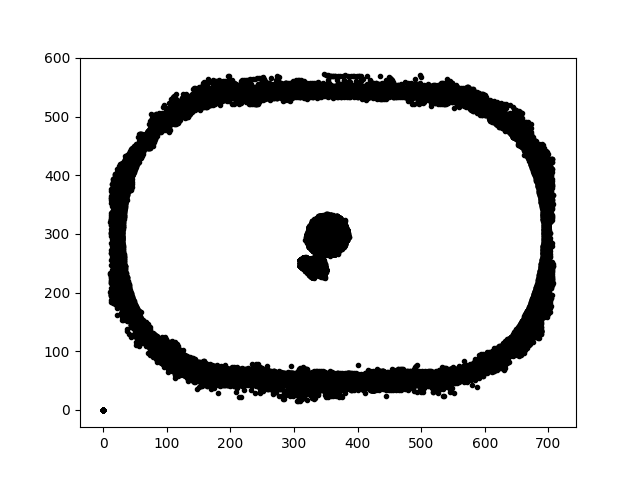

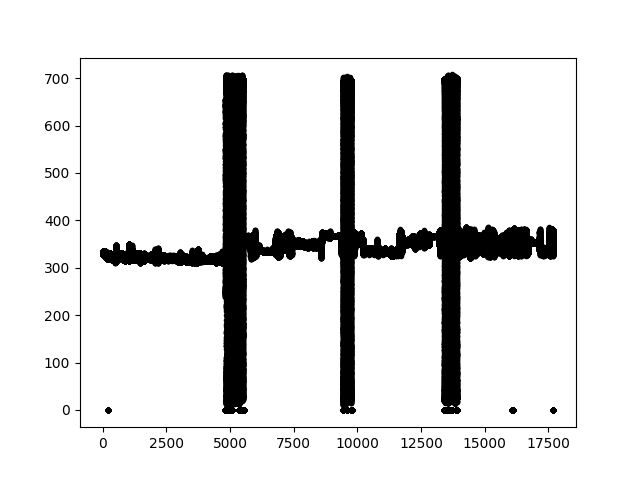

In [7]:
plt.figure()
plt.plot(x_coordinates, y_coordinates,'k.')
plt.show()

plt.figure()
plt.plot(track_time_vector, x_coordinates,'k.')
plt.show()

In [54]:
session = sessions[4]
shanks_electrodes,left_shanks,right_shanks = hc18_bf.get_shanks_info(session)
shanks_electrodes
# print(left_shanks)
# print(right_shanks)


[[0, 1, 3, 6, 2, 7, 4, 5],
 [10, 11, 13, 12, 14, 15, 9, 8],
 [21, 20, 19, 18, 17, 16, 22, 23],
 [27, 24, 31, 30, 25, 26, 29, 28],
 [36, 39, 38, 33, 35, 37, 34, 32],
 [43, 42, 47, 44, 46, 40, 41, 45],
 [51, 54, 50, 53, 55, 52, 49, 48],
 [56, 58, 59, 60, 57, 63, 61, 62],
 [64, 65, 67, 70, 66, 71, 68, 69],
 [74, 75, 76, 77, 78, 79, 72, 73],
 [80, 81, 82, 83, 84, 85, 86, 87],
 [88, 89, 90, 91, 92, 93, 94, 95],
 [96, 97, 98, 99, 103, 101, 100, 102],
 [104, 109, 105, 107, 106, 108, 111, 110],
 [117, 118, 112, 114, 113, 116, 115, 119],
 [122, 124, 127, 125, 123, 121, 120, 126]]

array([ 8,  9, 10, 11, 12, 13, 14, 15])

In [40]:
import xml.etree.ElementTree as ET

path = base_path + session
os.chdir(path)

# Load the XML file
tree = ET.parse(session + '.xml')  # Provide the actual filename
root = tree.getroot()

# Initialize the list to store channel groups
shanks_electrodes = []

# Find all channel groups
channel_groups = root.findall(".//channelGroups/group")

# Extract channels from each group
for group in channel_groups:
    channels = [int(channel.text) for channel in group.findall("channel")]
    print(channels)
    if channels:  # Check if the list of channels is not empty
        shanks_electrodes.append(channels)

# left_shanks = np.arange(0,8)
# right_shanks = np.arange(8,16)

[0, 1, 2, 3]
[4, 5, 6, 7]
[8, 9, 10, 11]
[12, 13, 14, 15]
[16, 17, 18, 19]
[20, 21, 22, 23]
[24, 25, 26, 27]
[28, 29, 30, 31]
[32, 33, 34, 35]
[36, 37, 38, 39]
[40, 41, 42, 43]
[44, 45, 46, 47]
[48, 49, 50, 51]
[52, 53, 54, 55]
[56, 57, 58, 59]
[60, 61, 62, 63]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]


In [ ]:

def get_shanks_info(session):

    path = base_path + session
    os.chdir(path)

    # Load the XML file
    tree = ET.parse(session + '.xml')  # Provide the actual filename
    root = tree.getroot()

    # Initialize the list to store channel groups
    shanks_electrodes = []

    # Find all channel groups
    channel_groups = root.findall(".//channelGroups/group")

    # Extract channels from each group
    for group in channel_groups:
        channels = [int(channel.text) for channel in group.findall("channel")]
        if channels:  # Check if the list of channels is not empty
            shanks_electrodes.append(channels)
    
    left_shanks = np.arange(0,8)
    right_shanks = np.arange(8,16)

    return 
    

In [3]:
event_name = 'SleepBaseline'
event_times, event_descriptions = hc18_bf.get_events(session, event_name)
print(event_descriptions)

In [18]:
for session in sessions:
    event_name = 'SleepBaseline'
    event_times, event_descriptions = hc18_bf.get_events(session, event_name)
    
    event_times = np.sort(np.array(event_times))
    event_start = np.nanmin(event_times)
    event_end = np.nanmax(event_times)
    print(event_end/60)

80.1340137485
88.28500000000001
67.70838802133333
84.18911932616668
84.50666666666666


In [31]:
base_path = "/media/apolo/projects/hc-18/data/"
path = base_path + session
os.chdir(path)

filename = session + '.cat.evt'

# Initialize events dictionary
events = {'time': [], 'description': []}

# Check if file exists

with open(filename, 'r') as file:
    lines = file.readlines()

